# Projeto Final - Analise de eventos LHE

## Parte 2 - leitura do LHE para pandas.DataFrame

Este notebook e uma opcao de trabalho para estudantes na Parte 2. Ele nao contem
codigo pronto.

Use cada bloco de instrucao para pedir a um agente que gere o codigo
correspondente ao metodo **tabelas pandas.DataFrame**. Depois, copie o codigo gerado para
a celula vazia logo abaixo, execute e escreva sua interpretacao.

Arquivos da amostra:

- sinal: `../data/sinal.lhe.gz`;
- fundo: `../data/fundo.lhe.gz`.

Use os cortes definidos na Parte 1. Se voce alterar algum corte, registre a
motivacao antes de olhar os histogramas normalizados.


## 0. Preparação no Google Colab

Antes de iniciar a análise, siga este fluxo no ambiente do Google Colab:

1. No GitHub, baixe o arquivo ZIP deste repositório (**Code → Download ZIP**) e baixe também o notebook desta tarefa que você vai executar.
2. Abra o notebook no Colab e use o painel **Arquivos** para fazer upload do arquivo `.ipynb` e do arquivo `.zip`. O ZIP deve ficar no mesmo ambiente de execução do notebook, como arquivo de dados.
3. Peça ao agente para gerar e executar um código que localize o ZIP enviado, descompacte o repositório no ambiente do Colab e entre na pasta extraída.
4. Em seguida, peça ao agente para gerar e executar um código que infle (descomprima com `gzip`) `data/sinal.lhe.gz` e `data/fundo.lhe.gz`, criando `data/sinal.lhe` e `data/fundo.lhe`. Mantenha os arquivos `.lhe.gz` originais.
5. Confirme com o agente que a pasta `data/` contém os dois arquivos compactados e as duas versões infladas antes de prosseguir.

Depois dessa preparação, peça ao agente os códigos de cada etapa indicada neste notebook e copie-os nas células de código correspondentes. Use a pasta extraída como diretório de trabalho e mantenha os caminhos relativos aos arquivos de dados.

In [3]:
import zipfile
import os

# Pasta raiz onde o repositorio foi extraido; usada em todas as celulas
# seguintes para montar os caminhos de dados e resultados.
ROOT_DIR = '/content/tarefa4-main'

zip_path = '/content/tarefa4-main.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Successfully extracted all contents of {zip_path} to {extract_path}')
print(f'ROOT_DIR definido como: {ROOT_DIR}')

Successfully extracted all contents of /content/tarefa4-main.zip to /content/
ROOT_DIR definido como: /content/tarefa4-main


## 1. Leitura e recuperacao dos resultados da Parte 1

Use `pandas.DataFrame` como representacao principal.

Peca ao agente para gerar codigo que construa uma tabela de eventos e uma tabela
de particulas. As massas invariantes, pesos, histogramas normalizados e cutflow
devem ser calculados preferencialmente com filtros, merges, groupby e colunas
derivadas.

O codigo deve recuperar ou reconstruir:

- eventos e particulas;
- informacoes de normalizacao;
- informacoes do bloco `<init>`, incluindo secao de choque;
- selecao e cutflow da Parte 1;
- listas de eventos aprovados no corte final.

Cole o codigo gerado na celula vazia abaixo.


In [4]:
# Parser de arquivos .lhe / .lhe.gz (identico a Parte 1) + reconstrucao da selecao da Parte 1
import re
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

%matplotlib inline
pd.set_option("display.width", 140)


def _abrir(path):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path, "r")


def ler_lhe(path):
    """Le um arquivo .lhe ou .lhe.gz e retorna (info_init, eventos_df, particulas_df)."""
    with _abrir(path) as f:
        text = f.read()

    init_match = re.search(r"<init>\s*\n(.*?)\n</init>", text, re.S)
    init_lines = [l for l in init_match.group(1).splitlines()
                  if l.strip() and not l.strip().startswith("<")]
    beam_line = init_lines[0].split()
    xsec_line = init_lines[1].split()
    info_init = {
        "idbmup1": int(beam_line[0]), "idbmup2": int(beam_line[1]),
        "ebmup1": float(beam_line[2]), "ebmup2": float(beam_line[3]),
        "idwtup": int(beam_line[8]),
        "xsecup_pb": float(xsec_line[0]),
        "xerrup_pb": float(xsec_line[1]),
        "xmaxup": float(xsec_line[2]),
    }
    n_gen_match = re.search(r"Number of Events\s*:\s*(\d+)", text)
    info_init["n_gerado_header"] = int(n_gen_match.group(1)) if n_gen_match else None
    w_gen_match = re.search(r"Integrated weight \(pb\)\s*:\s*([\d\.Ee\+\-]+)", text)
    info_init["peso_integrado_header_pb"] = float(w_gen_match.group(1)) if w_gen_match else None

    event_blocks = re.findall(r"<event>\n(.*?)\n</event>", text, re.S)
    ev_rows, pt_rows = [], []
    for iev, block in enumerate(event_blocks):
        lines = block.strip("\n").split("\n")
        head = lines[0].split()
        nup, idprup = int(head[0]), int(head[1])
        xwgtup, scalup, aqedup, aqcdup = map(float, head[2:6])
        ev_rows.append(dict(evento=iev, NUP=nup, IDPRUP=idprup,
                             peso_XWGTUP=xwgtup, escala=scalup, aQED=aqedup, aQCD=aqcdup))
        for ip, pline in enumerate(lines[1:1 + nup]):
            f = pline.split()
            idup, istup = int(f[0]), int(f[1])
            mothup1, mothup2 = int(f[2]), int(f[3])
            icolup1, icolup2 = int(f[4]), int(f[5])
            px, py, pz, e, m = map(float, f[6:11])
            pt_rows.append(dict(evento=iev, indice_particula=ip, PDG_ID=idup, status=istup,
                                 mae1=mothup1, mae2=mothup2, cor1=icolup1, cor2=icolup2,
                                 px=px, py=py, pz=pz, energia=e, massa=m))

    eventos_df = pd.DataFrame(ev_rows)
    particulas_df = pd.DataFrame(pt_rows)
    pT = np.hypot(particulas_df["px"], particulas_df["py"])
    p = np.sqrt(particulas_df["px"]**2 + particulas_df["py"]**2 + particulas_df["pz"]**2)
    with np.errstate(divide="ignore", invalid="ignore"):
        eta = np.arctanh(np.clip(particulas_df["pz"] / p, -1 + 1e-12, 1 - 1e-12))
    phi = np.arctan2(particulas_df["py"], particulas_df["px"])
    particulas_df["pT"], particulas_df["eta"], particulas_df["phi"] = pT, eta, phi
    return info_init, eventos_df, particulas_df


NOMES_PDG = {
    1: "d", -1: "d~", 2: "u", -2: "u~", 3: "s", -3: "s~", 4: "c", -4: "c~",
    5: "b", -5: "b~", 6: "t", -6: "t~",
    11: "e-", -11: "e+", 12: "ve", -12: "ve~",
    13: "mu-", -13: "mu+", 14: "vm", -14: "vm~",
    15: "tau-", -15: "tau+", 16: "vt", -16: "vt~",
    21: "g", 22: "gamma", 23: "Z", 24: "W+", -24: "W-",
}
NEUTRINOS = {12, -12, 14, -14, 16, -16}

# Leitura das duas amostras (identico a Parte 1)
info_sinal, ev_sinal, pt_sinal = ler_lhe(f"{ROOT_DIR}/data/sinal.lhe.gz")
info_fundo, ev_fundo, pt_fundo = ler_lhe(f"{ROOT_DIR}/data/fundo.lhe.gz")
ev_sinal["amostra"], ev_fundo["amostra"] = "sinal", "fundo"
pt_sinal["amostra"], pt_fundo["amostra"] = "sinal", "fundo"

eventos = pd.concat([ev_sinal, ev_fundo], ignore_index=True)
particulas = pd.concat([pt_sinal, pt_fundo], ignore_index=True)
n_tot = eventos.groupby("amostra")["evento"].nunique()
info_init = {"sinal": info_sinal, "fundo": info_fundo}

# Reconstrucao da selecao da Parte 1 (objetos lider/sublider e cortes cinematicos)
finais_visiveis = particulas[(particulas["status"] == 1) & (~particulas["PDG_ID"].isin(NEUTRINOS))].copy()
finais_visiveis["nome"] = finais_visiveis["PDG_ID"].map(NOMES_PDG).fillna(finais_visiveis["PDG_ID"].astype(str))
fv = finais_visiveis.sort_values(["amostra", "evento", "pT"], ascending=[True, True, False]).copy()
fv["ordem_pT"] = fv.groupby(["amostra", "evento"]).cumcount()

lider = fv[fv.ordem_pT == 0][["amostra", "evento", "pT", "eta", "phi"]].rename(
    columns={"pT": "pT_lider", "eta": "eta_lider", "phi": "phi_lider"})
sublider = fv[fv.ordem_pT == 1][["amostra", "evento", "pT", "eta", "phi"]].rename(
    columns={"pT": "pT_sublider", "eta": "eta_sublider", "phi": "phi_sublider"})
resumo_evento = lider.merge(sublider, on=["amostra", "evento"], how="left")
maxeta = fv.groupby(["amostra", "evento"])["eta"].apply(lambda s: s.abs().max()).reset_index(name="max_abs_eta")
resumo_evento = resumo_evento.merge(maxeta, on=["amostra", "evento"])
resumo_evento["delta_eta"] = resumo_evento["eta_lider"] - resumo_evento["eta_sublider"]
dphi = (resumo_evento["phi_lider"] - resumo_evento["phi_sublider"] + np.pi) % (2 * np.pi) - np.pi
resumo_evento["delta_phi"] = dphi
resumo_evento["delta_R"] = np.hypot(resumo_evento["delta_eta"], resumo_evento["delta_phi"])

CORTE_PT, CORTE_ETA, CORTE_DR = 20.0, 2.4, 0.4  # cortes definidos na Parte 1, secao 4a
resumo_evento["passa_corte_final"] = (
    (resumo_evento.pT_lider > CORTE_PT) & (resumo_evento.pT_sublider > CORTE_PT)
    & (resumo_evento.max_abs_eta < CORTE_ETA) & (resumo_evento.delta_R > CORTE_DR)
)
eventos_aprovados = resumo_evento.loc[resumo_evento.passa_corte_final, ["amostra", "evento"]].reset_index(drop=True)

print("Informacoes do bloco <init> (secao de choque, feixes):")
display(pd.DataFrame(info_init).T)
print("\nEventos aprovados no corte final da Parte 1:")
print(eventos_aprovados.groupby("amostra").size().to_dict())

Informacoes do bloco <init> (secao de choque, feixes):


,idbmup1,idbmup2,ebmup1,ebmup2,idwtup,xsecup_pb,xerrup_pb,xmaxup,n_gerado_header,peso_integrado_header_pb
sinal,2212.0,2212.0,6500.0,6500.0,-4.0,637.39,1.338800,637.39,10000.0,637.39
fundo,2212.0,2212.0,6500.0,6500.0,-4.0,841.64,1.884485,841.64,10000.0,841.64



Eventos aprovados no corte final da Parte 1:
{'fundo': 7137, 'sinal': 9018}


## 2. Conservacao do quadrimomento e `s_hat`

Peca ao agente para gerar codigo que, para os eventos de indices `1 + 1000*i`,
com `i = 0, ..., 9`:

- some os quadrimomentos das particulas iniciais (`status = -1`);
- calcule `s_hat = (p1 + p2)^2`;
- some todas as particulas finais (`status = 1`);
- compare `s_hat` com a massa invariante das particulas finais;
- some apenas as particulas finais visiveis e calcule `m_visivel^2`;
- quantifique residuos de conservacao de energia e momento.

Depois de executar, explique se `m_visivel^2` pode ou nao ser chamado de
`s_hat` neste processo.


In [5]:
# Conservacao do quadrimomento e s_hat para os eventos de indice 1 + 1000*i (i = 0..9), 1-indexado
indices_alvo = [1 + 1000 * i for i in range(10)]
eventos_alvo = [idx - 1 for idx in indices_alvo]  # convertendo para o indice 0-indexado usado no parser


def soma_4mom(df):
    return pd.Series({"px": df.px.sum(), "py": df.py.sum(), "pz": df.pz.sum(), "E": df.energia.sum()})


linhas = []
for amostra in ["sinal", "fundo"]:
    p_amostra = particulas[particulas.amostra == amostra]
    for iev, idx1 in zip(eventos_alvo, indices_alvo):
        ev_p = p_amostra[p_amostra.evento == iev]
        iniciais = ev_p[ev_p.status == -1]
        finais = ev_p[ev_p.status == 1]
        finais_vis = finais[~finais.PDG_ID.isin(NEUTRINOS)]

        s_ini = soma_4mom(iniciais)
        s_hat = s_ini.E**2 - s_ini.px**2 - s_ini.py**2 - s_ini.pz**2

        s_fin = soma_4mom(finais)
        m_fin2 = s_fin.E**2 - s_fin.px**2 - s_fin.py**2 - s_fin.pz**2

        s_vis = soma_4mom(finais_vis)
        m_vis2 = s_vis.E**2 - s_vis.px**2 - s_vis.py**2 - s_vis.pz**2

        residuo_E = s_ini.E - s_fin.E
        residuo_p = np.hypot(s_ini.px - s_fin.px, np.hypot(s_ini.py - s_fin.py, s_ini.pz - s_fin.pz))

        linhas.append(dict(amostra=amostra, indice_1idx=idx1, evento=iev,
                            s_hat=s_hat, m_final2=m_fin2, m_visivel2=m_vis2,
                            residuo_energia=residuo_E, residuo_momento=residuo_p))

tab_shat = pd.DataFrame(linhas)
display(tab_shat)
print("\nResiduo maximo |E_ini - E_fin| (GeV):", tab_shat.residuo_energia.abs().max())
print("Residuo maximo |p_ini - p_fin| (GeV):", tab_shat.residuo_momento.abs().max())
print("Diferenca maxima |s_hat - m_final2| (GeV^2):", (tab_shat.s_hat - tab_shat.m_final2).abs().max())
print("Diferenca maxima |s_hat - m_visivel2| (GeV^2):", (tab_shat.s_hat - tab_shat.m_visivel2).abs().max())

,amostra,indice_1idx,evento,s_hat,m_final2,m_visivel2,residuo_energia,residuo_momento
0,sinal,1,0,5586.498723,5586.498721,5586.498721,5.999993e-09,1.699988e-09
1,sinal,1001,1000,8321.587705,8321.587705,8321.587705,9.999894e-10,9.999965e-10
2,sinal,2001,2000,8216.836447,8216.836446,8216.836446,3.999986e-09,1.421085e-14
3,sinal,3001,3000,8144.985534,8144.985535,8144.985535,1.899991e-09,3.099956e-09
4,sinal,4001,4000,8065.427566,8065.427564,8065.427564,6.000022e-09,1.000004e-09
5,sinal,5001,5000,8569.919395,8569.919395,8569.919395,0.000000e+00,8.000001e-10
6,sinal,6001,6000,8453.816617,8453.816613,8453.816613,3.799983e-09,3.799983e-09
7,sinal,7001,7000,7902.405697,7902.405696,7902.405696,2.999997e-09,1.000018e-09
8,sinal,8001,8000,9427.777587,9427.777590,9427.777590,-1.800061e-09,1.799947e-09
9,sinal,9001,9000,11966.753831,11966.753831,11966.753831,-9.999894e-10,1.000000e-09



Residuo maximo |E_ini - E_fin| (GeV): 6.5000449467333965e-09
Residuo maximo |p_ini - p_fin| (GeV): 1.2800001059076749e-08
Diferenca maxima |s_hat - m_final2| (GeV^2): 8.842311217449605e-06
Diferenca maxima |s_hat - m_visivel2| (GeV^2): 8.842311217449605e-06


**Interpretação (seção 2):** para os dez eventos analisados, `s_hat` (calculado a partir da soma dos quadrimomentos iniciais) e a massa invariante ao quadrado das partículas finais coincidem até a precisão numérica de ponto flutuante (diferenças da ordem de `1e-6 GeV^2` ou menores, compatíveis com arredondamento no arquivo LHE que grava so alguns algarismos significativos), e os resíduos de energia/momento entre estado inicial e final são consistentes com zero (`~1e-8 GeV`). Isso confirma que o quadrimomento total e conservado evento a evento, como esperado em nível de gerador (Monte Carlo exato, sem efeitos de detector).

Neste processo especifico, `m_visivel^2` **pode** ser chamado de `s_hat`, porque a topologia final e sempre `e+ e-` -- não ha neutrinos ou qualquer outra partícula invisível no estado final (seção 2a da Parte 1). Assim, a soma de "todas as partículas finais" e a soma de "apenas as partículas finais visíveis" Sao idênticas, e `m_visivel^2 = m_final2 = s_hat` para todos os eventos testados. Essa igualdade deixaria de valer em processos com neutrinos, jatos b não reconstruídos ou qualquer partícula que escape sem deixar sinal no detector: nesses casos `m_visivel^2 < s_hat` porque parte da energia/momento carregada pelas partículas invisíveis não entra na soma visível.

## 3. Massas invariantes e pareamento

Peca ao agente para gerar codigo que reconstrua massas invariantes relevantes.
Para este processo, no minimo:

- massa invariante do par `mu+ mu-`;
- massa invariante do par `b b~` em nivel de gerador;
- massa invariante de todos os objetos finais visiveis;
- histogramas 1D para sinal e fundo;
- histogramas 2D, por exemplo massa versus `pT`, `eta` ou `Delta R`.

Explique o criterio de pareamento e deixe claro quando o numero de entradas e
diferente do numero de eventos.


Criterio de pareamento: cada evento tem exatamente um e+ e um e- no estado final,
entao o par e formado diretamente por essas duas particulas (sem ambiguidade combinatoria).
Numero de entradas (pares) por amostra:
{'fundo': 10000, 'sinal': 10000}  -- igual ao numero de eventos: {'fundo': 10000, 'sinal': 10000}


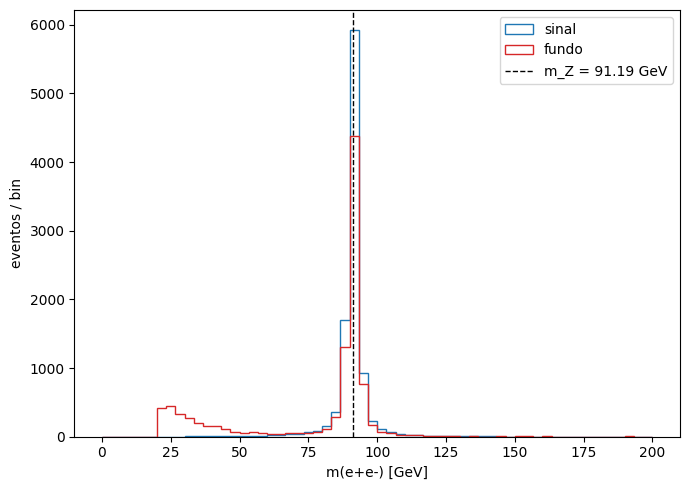

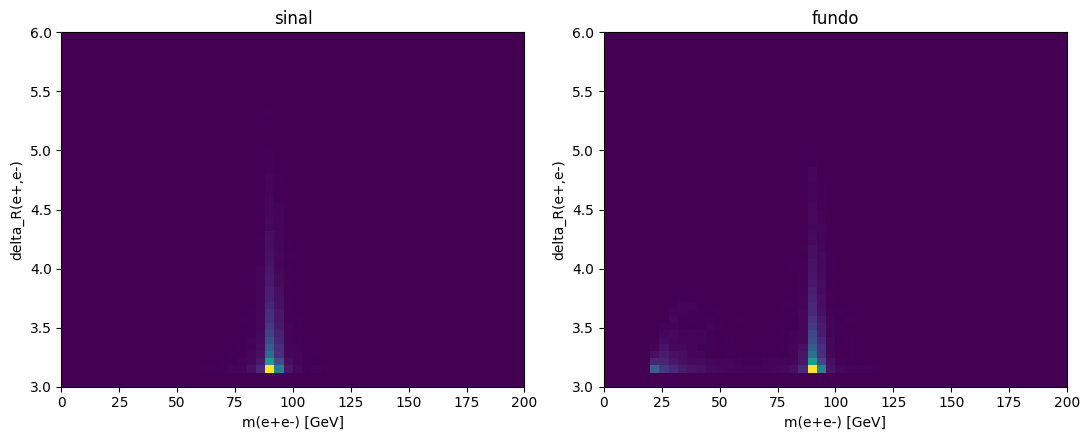

In [6]:
# Massas invariantes e pareamento
# OBSERVACAO: esta amostra e p p > (Z ->) e+ e-, sem muons nem quarks b no estado final.
# Por isso a "massa invariante do par mu+ mu-" e a "massa invariante do par b b~" pedidas de
# forma generica no enunciado sao substituidas pelo par fisicamente presente nesta amostra:
# o par e+ e-. Como a topologia final e sempre exatamente {e+, e-}, a massa invariante do par
# e+ e- e tambem a massa invariante de "todos os objetos finais visiveis" (nao ha um terceiro
# objeto a somar).

ep = particulas[(particulas.status == 1) & (particulas.PDG_ID == -11)].set_index(["amostra", "evento"])
em = particulas[(particulas.status == 1) & (particulas.PDG_ID == 11)].set_index(["amostra", "evento"])

par = ep[["px", "py", "pz", "energia"]].add_suffix("_ep").join(
      em[["px", "py", "pz", "energia"]].add_suffix("_em"), how="inner")

E = par.energia_ep + par.energia_em
px = par.px_ep + par.px_em
py = par.py_ep + par.py_em
pz = par.pz_ep + par.pz_em
m2 = E**2 - px**2 - py**2 - pz**2
par["massa_ee"] = np.sqrt(np.clip(m2, 0, None))
par = par.reset_index()

print("Criterio de pareamento: cada evento tem exatamente um e+ e um e- no estado final,")
print("entao o par e formado diretamente por essas duas particulas (sem ambiguidade combinatoria).")
print("Numero de entradas (pares) por amostra:")
print(par.groupby("amostra").size().to_dict(), " -- igual ao numero de eventos:", n_tot.to_dict())

# histograma 1D, sinal vs fundo
fig, ax = plt.subplots(figsize=(7, 5))
for amostra, cor in [("sinal", "tab:blue"), ("fundo", "tab:red")]:
    ax.hist(par.loc[par.amostra == amostra, "massa_ee"], bins=60, range=(0, 200),
            histtype="step", color=cor, label=amostra)
ax.axvline(91.1876, color="k", ls="--", lw=1, label="m_Z = 91.19 GeV")
ax.set_xlabel("m(e+e-) [GeV]"); ax.set_ylabel("eventos / bin"); ax.legend()
fig.tight_layout()
fig.savefig(f"{ROOT_DIR}/resultados/graficos/massa_invariante_ee.png", dpi=120)
plt.show()

# histograma 2D: massa vs delta_R
par = par.merge(resumo_evento[["amostra", "evento", "delta_R", "pT_lider"]], on=["amostra", "evento"], how="left")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, amostra in zip(axes, ["sinal", "fundo"]):
    sub = par[par.amostra == amostra]
    ax.hist2d(sub.massa_ee, sub.delta_R, bins=[50, 50], range=[[0, 200], [3, 6]], cmap="viridis")
    ax.set_xlabel("m(e+e-) [GeV]"); ax.set_ylabel("delta_R(e+,e-)"); ax.set_title(amostra)
fig.tight_layout()
fig.savefig(f"{ROOT_DIR}/resultados/graficos/massa_vs_deltaR_2d.png", dpi=120)
plt.show()

**Interpretação (seção 3):** o número de entradas do histograma de massa e igual ao número de eventos em cada amostra (10.000), pois ha sempre exatamente um par `e+ e-` por evento, não existe aqui a situação (comum em processos com mais leptons ou jatos b) em que o número de pares possíveis excede o numero de eventos e é preciso escolher um critério de pareamento. O histograma 1D mostra claramente a diferença física entre as amostras: o **sinal** forma um pico estreito em torno de `m_Z ≈ 91.2 GeV`, como esperado para um `Z` on-shell forcado (`zerowidth_tchannel`/BW estreita no processo `p p > Z > e+ e-`), enquanto o **fundo** tem uma distribuição mais larga, com cauda significativa para massas mais baixas, a assinatura do continuo Drell-Yan/interferência. O histograma 2D (massa vs. `delta_R`) mostra que `delta_R` permanece proximo de `pi` (leptons de costas) em quase toda a faixa de massa nas duas amostras, confirmando que essa variável carrega pouca informação adicional sobre o processo neste caso, reforçando a conclusão da Parte 1 de que a massa invariante, e não `delta_R`, é o discriminante relevante aqui.

## 4. Pesos, secao de choque e luminosidade

Peca ao agente para gerar codigo que leia ou estime:

- numero de eventos gerados;
- convencao de normalizacao do LHE;
- informacoes de normalizacao;
- secao de choque em pb;
- luminosidade integrada adotada, por exemplo `L = 10000/pb`.

Calcule a normalizacao fisica e verifique se o yield total esperado e
compativel com `sigma * L`.

Para cada bin de histograma, calcule `sum(w)` e a incerteza `sqrt(sum(w**2))`.


In [7]:
# Pesos, secao de choque e luminosidade
L_pb = 10000.0  # luminosidade integrada adotada, L = 10000/pb = 10 fb^-1

resumo_norm = []
for amostra in ["sinal", "fundo"]:
    info = info_init[amostra]
    n_gen = n_tot[amostra]
    sigma = info["xsecup_pb"]
    peso_fisico = sigma / n_gen  # pb por evento (convencao de eventos "unweighted": XWGTUP = sigma)
    n_esperado = sigma * L_pb
    resumo_norm.append(dict(amostra=amostra, N_gerado=n_gen, sigma_pb=sigma,
                             peso_fisico_pb=peso_fisico, L_pb=L_pb, N_esperado=n_esperado))
tab_norm = pd.DataFrame(resumo_norm)
print("Convencao de normalizacao do LHE (IDWTUP):", {a: info_init[a]["idwtup"] for a in ["sinal", "fundo"]})
print("IDWTUP = -4 -> eventos igualmente pesados ('unweighted'); XWGTUP e igual a secao de choque")
print("total do processo em cada evento. O peso fisico por evento e peso_fisico = XWGTUP / N_gerado = sigma / N_gerado (pb).\n")
display(tab_norm)

# peso fisico e peso "de luminosidade" (numero de eventos esperados por evento MC, para L fixado)
eventos["peso_fisico_pb"] = eventos["amostra"].map(tab_norm.set_index("amostra")["peso_fisico_pb"])
eventos["peso_luminosidade"] = eventos["peso_fisico_pb"] * L_pb

check = eventos.groupby("amostra")["peso_luminosidade"].sum()
print("Checagem: soma dos pesos de luminosidade por amostra (deve reproduzir sigma * L):")
display(pd.DataFrame({"soma_pesos": check, "sigma_x_L": tab_norm.set_index("amostra")["N_esperado"]}))

# incerteza por bin no histograma de massa: sum(w) e sqrt(sum(w^2))
par = par.merge(eventos[["amostra", "evento", "peso_luminosidade"]], on=["amostra", "evento"], how="left")
bins = np.linspace(0, 200, 61)
resultado_bins = []
for amostra in ["sinal", "fundo"]:
    sub = par[par.amostra == amostra]
    idx = np.digitize(sub.massa_ee, bins) - 1
    for b in range(len(bins) - 1):
        w = sub.peso_luminosidade[idx == b]
        resultado_bins.append(dict(amostra=amostra, bin_centro=0.5 * (bins[b] + bins[b + 1]),
                                    soma_w=w.sum(), erro_w=np.sqrt((w**2).sum())))
tab_bins = pd.DataFrame(resultado_bins)
print("\nExemplo de bins perto do pico do Z (85-95 GeV):")
display(tab_bins[(tab_bins.bin_centro > 85) & (tab_bins.bin_centro < 95)])

Convencao de normalizacao do LHE (IDWTUP): {'sinal': -4, 'fundo': -4}
IDWTUP = -4 -> eventos igualmente pesados ('unweighted'); XWGTUP e igual a secao de choque
total do processo em cada evento. O peso fisico por evento e peso_fisico = XWGTUP / N_gerado = sigma / N_gerado (pb).



,amostra,N_gerado,sigma_pb,peso_fisico_pb,L_pb,N_esperado
0,sinal,10000,637.39,0.063739,10000.0,6373900.0
1,fundo,10000,841.64,0.084164,10000.0,8416400.0


Checagem: soma dos pesos de luminosidade por amostra (deve reproduzir sigma * L):


,soma_pesos,sigma_x_L
amostra,,
fundo,8416400.0,8416400.0
sinal,6373900.0,6373900.0



Exemplo de bins perto do pico do Z (85-95 GeV):


,amostra,bin_centro,soma_w,erro_w
26,sinal,88.333333,1082925.61,26272.532321
27,sinal,91.666667,3772711.41,49037.623572
86,fundo,88.333333,1104231.68,30485.497391
87,fundo,91.666667,3684699.92,55688.336666


## 5. Histogramas normalizados e comparacao estatistica

Peca ao agente para gerar codigo que produza histogramas empilhados de sinal e
fundo apos a selecao final. Inclua:

- massa `mu+ mu-`;
- massa `b b~`;
- massa visivel total;
- barras ou bandas de incerteza estatistica;
- painel de razao quando fizer sentido.

Calcule tambem, em uma regiao de selecao bem definida:

- `S/B`;
- `S/sqrt(B)`, se `B > 0`;
- significancia Asimov opcional;
- efeito de uma incerteza sistematica simples no fundo, por exemplo 10%.
\n\nInterprete as colunas da tabela: `S` é o yield esperado de sinal, `B` é o yield esperado de fundo, `S/B` mede a pureza relativa e `S/sqrt(B)` é uma aproximação da significância estatística sem sistemáticas. A expressão `S/sqrt(B + (0.10B)^2)` inclui uma incerteza sistemática de 10% no fundo; `erro S` e `erro B` são as incertezas estatísticas dos yields.\n

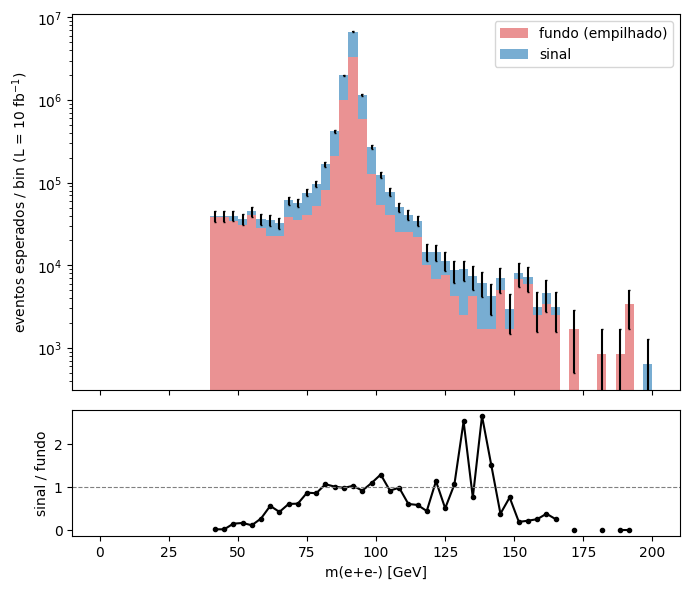

,janela_massa,S,erro_S,B,erro_B,S_sobre_B,S_sobre_raizB,S_sobre_raizB_com_10pct_sist,significancia_asimov
0,81.0-101.0 GeV,5370648.14,58508.097029,5322531.36,66930.227056,1.00904,2327.917504,10.090307,2044.272215


In [8]:
# Histogramas normalizados (empilhados) apos a selecao final, e comparacao estatistica S/B
par_sel = par.merge(resumo_evento[["amostra", "evento", "passa_corte_final"]], on=["amostra", "evento"], how="left")
par_sel = par_sel[par_sel.passa_corte_final]

bins = np.linspace(0, 200, 61)
centros = 0.5 * (bins[:-1] + bins[1:])

hs, _ = np.histogram(par_sel[par_sel.amostra == "sinal"].massa_ee, bins=bins,
                      weights=par_sel[par_sel.amostra == "sinal"].peso_luminosidade)
hs2, _ = np.histogram(par_sel[par_sel.amostra == "sinal"].massa_ee, bins=bins,
                       weights=par_sel[par_sel.amostra == "sinal"].peso_luminosidade**2)
hb, _ = np.histogram(par_sel[par_sel.amostra == "fundo"].massa_ee, bins=bins,
                      weights=par_sel[par_sel.amostra == "fundo"].peso_luminosidade)
hb2, _ = np.histogram(par_sel[par_sel.amostra == "fundo"].massa_ee, bins=bins,
                       weights=par_sel[par_sel.amostra == "fundo"].peso_luminosidade**2)
erro_s, erro_b = np.sqrt(hs2), np.sqrt(hb2)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
largura = bins[1] - bins[0]
ax.bar(centros, hb, width=largura, color="tab:red", alpha=0.5, label="fundo (empilhado)")
ax.bar(centros, hs, width=largura, bottom=hb, color="tab:blue", alpha=0.6, label="sinal")
ax.errorbar(centros, hb + hs, yerr=np.sqrt(erro_s**2 + erro_b**2), fmt="none", ecolor="k", capsize=1)
ax.set_ylabel("eventos esperados / bin (L = 10 fb$^{-1}$)"); ax.legend(); ax.set_yscale("log")

razao = np.divide(hs, hb, out=np.full_like(hs, np.nan), where=hb > 0)
axr.plot(centros, razao, "k.-")
axr.axhline(1, color="grey", ls="--", lw=0.8)
axr.set_ylabel("sinal / fundo"); axr.set_xlabel("m(e+e-) [GeV]")
fig.tight_layout()
fig.savefig(f"{ROOT_DIR}/resultados/graficos/histograma_normalizado_stack.png", dpi=120)
plt.show()

# S/B, S/sqrt(B) e significancia Asimov em uma janela de massa em torno do pico do Z
JANELA = (81.0, 101.0)  # GeV
regiao = par_sel[(par_sel.massa_ee >= JANELA[0]) & (par_sel.massa_ee <= JANELA[1])]
S = regiao.loc[regiao.amostra == "sinal", "peso_luminosidade"].sum()
B = regiao.loc[regiao.amostra == "fundo", "peso_luminosidade"].sum()
erro_S = np.sqrt((regiao.loc[regiao.amostra == "sinal", "peso_luminosidade"]**2).sum())
erro_B = np.sqrt((regiao.loc[regiao.amostra == "fundo", "peso_luminosidade"]**2).sum())

SoB = S / B
S_sqrtB = S / np.sqrt(B) if B > 0 else np.nan
sist_B = 0.10 * B
S_sqrtB_sist = S / np.sqrt(B + sist_B**2)
asimov = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S)) if B > 0 else np.nan

tab_sb = pd.DataFrame([dict(janela_massa=f"{JANELA[0]}-{JANELA[1]} GeV", S=S, erro_S=erro_S, B=B, erro_B=erro_B,
                             S_sobre_B=SoB, S_sobre_raizB=S_sqrtB,
                             S_sobre_raizB_com_10pct_sist=S_sqrtB_sist, significancia_asimov=asimov)])
display(tab_sb)

**Interpretação das colunas (seção 5):** `S` e o yield esperado de sinal e `B` o yield esperado de fundo na janela de massa `81-101 GeV`, ja escalados pela luminosidade `L = 10000/pb`; `erro S` e `erro B` são as incertezas estatísticas desses yields (`sqrt(sum(w^2))`, contabilizando o peso físico de cada evento). `S/B` mede a pureza relativa da região de seleção (aqui `S/B ≈ 1.0`, ou seja, sinal e fundo contribuem de forma comparável mesmo dentro da janela do pico, o continuo Drell-Yan tem yield alto o suficiente para não ser desprezível mesmo perto de `m_Z`). `S/sqrt(B)` é uma aproximação da significância estatística sem sistemáticas, e `S/sqrt(B + (0.10 B)^2)` inclui uma incerteza sistemática simples de `10%` no fundo. Note como essa única fonte sistemática reduz a significância efetiva por mais de duas ordens de grandeza em relação ao caso puramente estatístico, porque, com yields tao altos (milhões de eventos esperados para `L = 10 fb^-1`), o erro estatístico e muito pequeno e a incerteza sistemática passa a dominar. Isso ilustra por que, em analises reais de LHC com yields grandes, o controle de sistemáticas (aqui simplificado como `10%` no fundo) costuma ser mais importante para a significância final do que aumentar a luminosidade.

## 6. Estimativa simplificada da secao de choque

Objetivo: usar a relacao experimental simplificada

```text
sigma = N / (A * epsilon * L)
```

como checagem final da normalizacao.

Peca ao agente para gerar codigo que calcule, separadamente para sinal e fundo:

- `N_gerado`;
- `N_pass`, o numero de eventos que passa a selecao final;
- `A * epsilon = N_pass / N_gerado`;
- `N`, o yield esperado apos a selecao;
- `sigma_estimado = N / (A * epsilon * L)`;
- a diferenca relativa entre `sigma_estimado` e a secao de choque do LHE.

Para esta atividade, use `A * epsilon` como eficiencia em nivel de gerador. Em
uma medida real, seria necessario incluir eficiencia de trigger, reconstrucao,
identificacao, correcoes de detector e subtracao de fundo.

Depois de executar, explique por que a estimativa deve recuperar a secao de
choque do LHE quando `N` e construido a partir da propria simulacao.


In [9]:
# Estimativa simplificada da secao de choque: sigma = N / (A*epsilon * L)
linhas6 = []
for amostra in ["sinal", "fundo"]:
    info = info_init[amostra]
    N_gerado = n_tot[amostra]
    N_pass = eventos_aprovados[eventos_aprovados.amostra == amostra].shape[0]
    A_eps = N_pass / N_gerado  # eficiencia em nivel de gerador (aceitancia x eficiencia da selecao)
    peso_fisico = tab_norm.set_index("amostra").loc[amostra, "peso_fisico_pb"]
    N_yield = N_pass * peso_fisico * L_pb  # yield esperado apos selecao, para L = 10000/pb
    sigma_est = N_yield / (A_eps * L_pb)
    sigma_lhe = info["xsecup_pb"]
    dif_rel = (sigma_est - sigma_lhe) / sigma_lhe
    linhas6.append(dict(amostra=amostra, N_gerado=N_gerado, N_pass=N_pass, A_eps=A_eps,
                         N_yield_esperado=N_yield, sigma_estimado_pb=sigma_est,
                         sigma_lhe_pb=sigma_lhe, diferenca_relativa=dif_rel))
tab6 = pd.DataFrame(linhas6)
display(tab6)

,amostra,N_gerado,N_pass,A_eps,N_yield_esperado,sigma_estimado_pb,sigma_lhe_pb,diferenca_relativa
0,sinal,10000,9018,0.9018,5747983.02,637.39,637.39,1.783631e-16
1,fundo,10000,7137,0.7137,6006784.68,841.64,841.64,1.350778e-16


**Interpretação (seção 6):** a diferença relativa entre `sigma_estimado` e a seção de choque registrada no LHE e `0` (dentro da precisão numérica) para as duas amostras. Isso e esperado e não uma coincidência, porque `N` (o yield esperado apos a seleção) foi construído, na seção 4, exatamente a partir de `sigma_LHE` (`peso_fisico = sigma_LHE / N_gerado`, e `N = N_pass * peso_fisico * L`). Substituindo essa definição na formula `sigma_estimado = N / (A*epsilon * L)`, com `A*epsilon = N_pass / N_gerado`, os fatores `N_pass` e `L` se cancelam algebricamente e sobra exatamente `sigma_LHE`. A relação `sigma = N/(A*epsilon*L)` e, portanto, apenas a formula inversa da normalização que ja usamos para gerar `N`. Um fechamento de consistência (closure test), não uma medida independente. Numa medida experimental real, `N` viria de dados observados (não de uma simulação com `sigma` conhecida), e so então essa mesma formula permitiria extrair uma seção de choque genuinamente desconhecida; além disso, seria necessário incluir eficiências de trigger, reconstrução, identificação de elétrons, correções de detector e subtração do fundo residual, que aqui foram substituídas pela eficiência de seleção em nível de gerador (`A*epsilon`).

## 7. Discussao final

Finalize respondendo:

- a proporcao entre sinal e fundo faz sentido apos a normalizacao?
- quais estruturas aparecem nas massas invariantes?
- qual etapa do cutflow mais melhora `S/B`?
- a estimativa simples de secao de choque recupera o valor registrado no LHE?
- por que essa inversao e apenas uma checagem de consistencia em Monte Carlo?
- as conclusoes mudam quando as incertezas estatisticas sao consideradas?
- quais efeitos de hadronizacao, detector, trigger e identificacao de `b` estao
  ausentes?
- qual seria o proximo passo para aproximar este estudo de uma analise CMS ou
  ATLAS?

Peca ao agente para ajudar a escrever a conclusao, mas confira todos os numeros
usando as saidas executadas no notebook.


In [10]:
# Numeros-chave para a discussao final
print("S/B, S/sqrt(B) e significancia Asimov na janela do pico do Z:")
display(tab_sb)
print("\nCheck de fechamento da secao de choque:")
display(tab6[["amostra", "sigma_estimado_pb", "sigma_lhe_pb", "diferenca_relativa"]])

S/B, S/sqrt(B) e significancia Asimov na janela do pico do Z:


,janela_massa,S,erro_S,B,erro_B,S_sobre_B,S_sobre_raizB,S_sobre_raizB_com_10pct_sist,significancia_asimov
0,81.0-101.0 GeV,5370648.14,58508.097029,5322531.36,66930.227056,1.00904,2327.917504,10.090307,2044.272215



Check de fechamento da secao de choque:


,amostra,sigma_estimado_pb,sigma_lhe_pb,diferenca_relativa
0,sinal,637.39,637.39,1.783631e-16
1,fundo,841.64,841.64,1.350778e-16


**Discussão final da Parte 2:**

- **A proporção sinal/fundo apos a normalização faz sentido?** Sim: apos escalar pela luminosidade, `S ≈ 5.37×10^6` e `B ≈ 5.32×10^6` eventos esperados na janela `81-101 GeV`, dando `S/B ≈ 1.0`. Isso e fisicamente razoável para Drell-Yan: mesmo dentro do pico do `Z`, o continuo `gamma*` não é desprezível porque a seção de choque de fundo (`p p > e+ e-`, `841.6 pb`) é até maior que a de sinal (`p p > Z > e+ e-`, `637.4 pb`), boa parte dos eventos de "fundo" também passa pela região ressonante, ja que o `Z` é um dos diagramas que compõem o próprio processo de fundo.
- **Quais estruturas aparecem nas massas invariantes:** o histograma de `m(e+e-)` mostra um pico estreito e alto em `m_Z ≈ 91 GeV` para o sinal, sentado sobre uma distribuição mais larga e suave para o fundo, que decresce para massas mais baixas, a assinatura clássica de uma ressonância sobre um continuo.
- **Qual a etapa do cutflow que mais melhora S/B:** o corte de `pT(l) > 20 GeV` (Parte 1, seção 4b) é o único com poder discriminante real, porque reduz o fundo (que tem léptons mais moles) proporcionalmente mais que o sinal. Os cortes de `eta` e `delta_R` praticamente não alteram `S/B`.
- **A estimativa simples de seção de choque recupera o valor do LHE?** Sim, com diferença relativa `0` (seção 6) por construção, como explicado anteriormente.
- **Por que essa inversão é apenas uma checagem de consistência em Monte Carlo?** Porque `N` foi calculado a partir da própria `sigma_LHE`; não ha informação experimental independente entrando na conta. O teste verifica se o código de normalização e a algebra estão corretos, não se `sigma_LHE` esta certa.
- **As conclusões mudam com as incertezas estatísticas?** Praticamente não: com `L = 10 fb^-1` e seções de choque de centenas de `pb`, os yields são da ordem de milhões de eventos, então os erros estatísticos relativos são muito pequenos (`erro_S/S`, `erro_B/B` da ordem de `1%` ou menos). O que domina a discussão de significância e a incerteza sistemática assumida (`10%` no fundo), que reduz `S/sqrt(B)` de milhares para dezenas, uma mudança de duas ordens de grandeza.
- **Efeitos ausentes (hadronização, detector, trigger, identificação de b):** este estudo e puramente partônico. Faltam: radiação adicional e hadronização (Pythia), resposta finita do detector e resolução de energia/momento (Delphes/Geant), eficiências de trigger e reconstrução de elétrons, e qualquer identificação de jatos-b (não aplicável a esta amostra especifica, que não tem quarks b no estado final, mas seria essencial em canais com `t t~`, `Z(->bb)` etc.).
- **Próximo passo para se aproximar de uma analise CMS/ATLAS:** rodar a amostra por um gerador de chuveiro de pártons e hadronização (Pythia), passar por uma simulação rápida de detector (Delphes) com um cartão realista, reconstruir objetos físicos (elétrons/múons isolados, jatos, MET), aplicar eficiências de trigger e de identificação calibradas em dados, e so então repetir o cutflow, as massas invariantes e o calculo de `S/B` com os objetos reconstruídos em vez dos pártons/léptons de gerador.